# create two types of toy data, 

- both are spatially biased,
- one have all genes uniformly distributed (check if this has r2 ==0 ) 
- the other one has genes differentially distributed across the space 

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 

# simulate spots in space 
create `S`

In [2]:
N = 1000

ratio = 0.94 # how much of them are on dorsal 
x0 = 0 # the middle 
z0 = 0 # the middle 

yA_range = np.array((0,8))
yB_range = np.array((8,10))

In [3]:
S0 = np.random.normal(x0, size=N)
S2 = np.random.normal(z0, size=N)

In [4]:

S1B = np.random.uniform(yB_range[0],yB_range[1],size = int(N*ratio))
S1A = np.random.uniform(yA_range[0],yA_range[1],size = (N-len(S1B)))
S1 = np.r_[S1A,S1B]

In [5]:
S = np.c_[S0,S1,S2]

In [6]:
S.shape

(1000, 3)

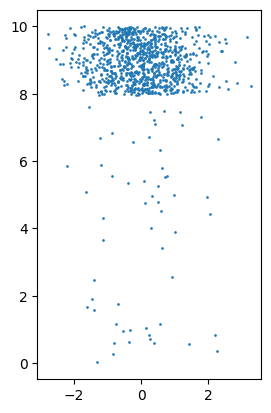

In [7]:
plt.scatter(S[:,0],S[:,1],s=1,alpha = .9)
plt.gca().set_aspect('equal')

# simulate two types of gene expression 
their mean will range from 1 to 77, i guess

In [8]:
G = 77

genedata1 = np.clip(np.concatenate([np.random.normal(g+4, np.sqrt(g+1), size = N)[:,None] for g in range(G)], axis = 1), 0, None)


In [9]:
genedata1.shape

(1000, 77)

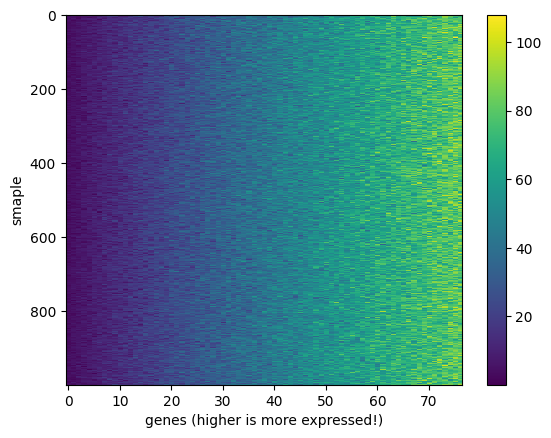

In [10]:
plt.imshow(genedata1, aspect = 'auto', interpolation = 'nearest')
plt.ylabel('smaple');plt.xlabel('genes (higher is more expressed!)')
plt.colorbar()

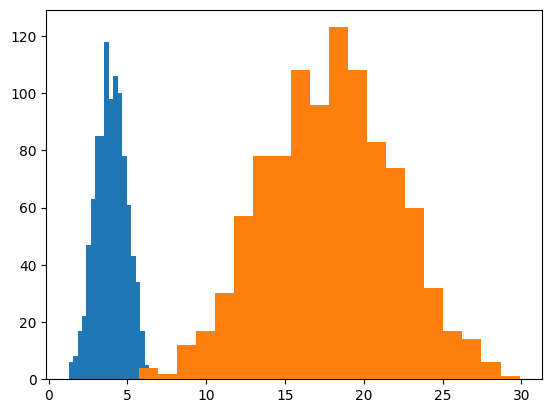

In [11]:
plt.hist(genedata1[:,0], bins = 20);
plt.hist(genedata1[:,14], bins = 20);

In [12]:

def generate_correlated(S1, r, mean=0.0, variance=1.0, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    S1 = np.asarray(S1, dtype=float)
    N = S1.shape[0]

    # Standardize S1
    S1c = (S1 - S1.mean()) / S1.std(ddof=0)

    # Generate independent noise
    Z = np.random.randn(N)
    Zc = (Z - Z.mean()) / Z.std(ddof=0)

    # Mix to achieve desired correlation
    X_gc = r * S1c + np.sqrt(1 - r**2) * Zc
    X_g = X_gc * np.sqrt(variance) + mean # Scale to desired variance and mean
    return X_g

In [13]:
genedata1.shape

(1000, 77)

In [14]:
foo = np.clip(np.random.normal(0.8, 0.05, size = 100)*(np.random.choice([1, -1], size = 100)),-1,1)

In [16]:
np.random.seed(422)
correlated_genes_id = np.random.choice(np.arange(G), size = int(G*0.1), replace = False)

genedata2 = genedata1.copy()
for g in correlated_genes_id:
    random_correlation = np.clip(np.random.normal(0.8, 0.05, size = 1)*(np.random.choice([1, -1], size = 1)),-1,1)
    new_expr = generate_correlated(S1, r=random_correlation, mean=g+4, variance=np.sqrt(g+1), random_state=g)
    genedata2[:,g] = new_expr

In [20]:

import sys
sys.path.append('../func/')
import cca_analysis 
cca_analysis.main(genedata1, S)


Canonical correlation for component 1 is low: 0.321. Skipping plot.
Canonical correlation for component 2 is low: 0.273. Skipping plot.
Canonical correlation for component 3 is low: 0.221. Skipping plot.


[ 7.46219752e-03  9.99971850e-01 -7.84635107e-04]


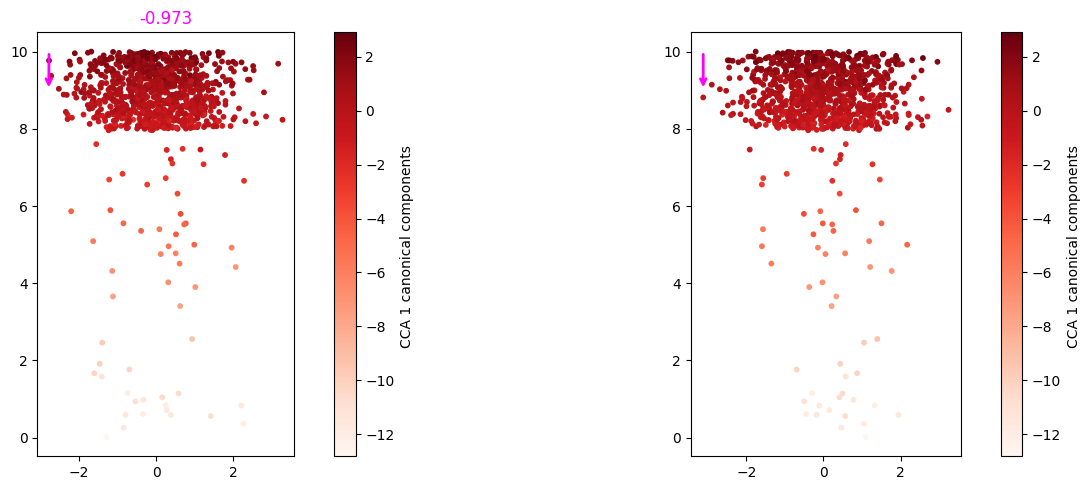

Canonical correlation for component 2 is low: 0.309. Skipping plot.
Canonical correlation for component 3 is low: 0.272. Skipping plot.


In [23]:
cca_analysis.main(genedata2, S,plot_mesh_flag=False)